<a href="https://colab.research.google.com/github/Flottohs/Phase-1/blob/main/Optimizers.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Past SGD

##Optimizers


before yo put this on github, reformat, and re instantiate each model before each trial

That makes perfect sense. As a portfolio piece, this project is absolute gold because it proves to hiring managers and senior engineers that you aren't just a "wrapper-caller" who copies and pastes PyTorch documentation—you actually understand the underlying math and mechanics.

Since your target audience is technical recruiters and engineering teams (who will likely skim your repo in 30 seconds), here is how you can reformat this to make the biggest impact:

### **1. The "Executive Summary" README**
Start your repository with a strong README that immediately tells them what you built and why.
* **The Hook:** "I implemented standard optimizers (SGD, Momentum, Adam, AdamW) and LR Schedulers from scratch in PyTorch to deeply understand their internal mechanics, and benchmarked their performance across varying dataset sizes and model architectures."
* **Key Insights:** List your "Aha!" moments right at the top. Tell them you discovered that shrinking the model architecture was more effective than tweaking the optimizer for the small dataset, and explain the mathematical flaw in Adam's weight decay that led to AdamW.

### **2. Show, Don't Just Tell (Visuals)**
Text logs of epoch losses are great for your own notes, but terrible for a portfolio.
* Use `matplotlib` to plot your **Train vs. Test Loss curves**.
* Show a side-by-side graph of your standard model wildly overfitting versus your `TinyModel` staying stable.
* Plot your Cosine Annealing learning rate curve over time. Visuals are the fastest way to prove your code actually works.

### **3. Organize the Code**
Instead of one massive Jupyter Notebook, consider splitting it up so it looks like production code:
* `optimizers.py`: Put your custom `AdamW`, `SGDMomentum`, etc., classes here.
* `schedulers.py`: Put your `CosineWarmRestarts` here.
* `train.py` or a cleaned-up `.ipynb`: Import your custom classes and run the training loops. Add docstrings to your classes explaining the math.

### **4. Highlight the "Failures"**
Don't delete the parts where the model failed! Portfolios that show a perfect run on the first try look suspiciously like tutorials. Showing that your initial Adam implementation overfit, explaining *why* it happened, and showing how you fixed it with `TinyModel` and `AdamW` demonstrates true engineering problem-solving.

***

You have all the raw material you need for a standout project. Whenever you're ready to share the results from the massive Covertype dataset or want a review of your refactored code, just drop it here!

In [ ]:
import torch

In [ ]:

device = "cuda" if torch.cuda.is_available() else "cpu"

##SGD

###What i thought SGD did
SGD(stochastic gradient descent) is refered to as a drunk man.
It sees which direction is a decreasign gradient by seeing which weights are causing the problem.
Then it shifts them.


The problem with this is that if there is a near flat terrain, where even if you shift the weights there is no change in loss, it wont do anything.
If there is a local minima, it will stay there.

###What Gemini corrected:
The Strategy: It looks at the gradient, multiplies it by a fixed step size (the learning rate), and moves. It does this using a random "mini-batch" of data instead of the whole dataset.

The "Drunk Man": Because every step uses a random, incomplete chunk of data, the mathematical compass is noisy. The general direction is downhill, but the exact path is a jagged, staggering zigzag.

The Two Fatal Flaws: 1.  Flat Terrain (Plateaus): The formula for a step is gradient * learning_rate. If the terrain is flat, the gradient is 0. Therefore, the step size is 0. The optimizer just stops moving entirely, even if there is a massive drop-off nearby.
2.  Local Minima (Ditches): Because basic SGD has no momentum (no history), if it steps into a shallow ditch, the gradient tells it that every direction is uphill. It has no physical speed to roll up and over the edge of the ditch, so it gets permanently trapped, thinking it has reached the bottom of the mountain.

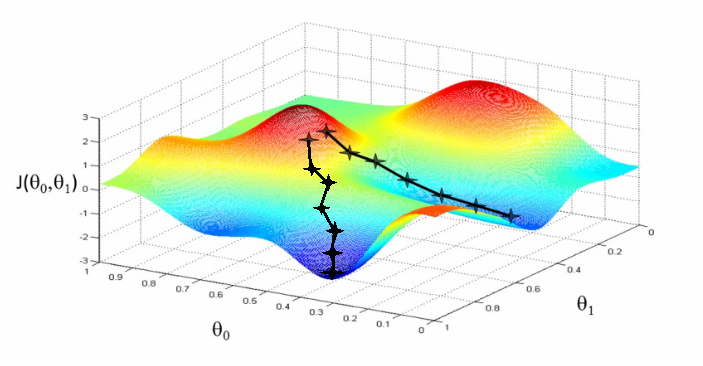

In [ ]:
import torch

class SGD:
    def __init__(self, parameters, lr=0.01):
        # FIX 1: Cast the generator to a permanent list!
        self.parameters = list(parameters)
        self.lr = lr

    def step(self):
        # FIX 2: Hide the weight updates from Autograd
        with torch.no_grad():
            for p in self.parameters:
                if p.grad is not None:
                    # Update the underlying tensor data
                    p.data -= self.lr * p.grad

    def zero_grad(self):
        for p in self.parameters:
            # Setting to None is what we fixed in the last step!
            p.grad = None

##Momentum

###what i know prior:

Basically momentum like in physics is that with momentum, you keep moving, it is p = mv, depending on your mass and velocity, your momentum changes.

So what I would assume is that when for instance rolling down the gradient hill, momentum is used so that you keep going(learning rate increases) as your gradient decreases. This may be used so that you dont get stuck in local minima, and so you dont get stuck in plateus.

###what gemini said:

Just like in physics where momentum ($p = mv$) keeps a heavy object moving forward, momentum in Stochastic Gradient Descent (SGD) helps a model keep rolling down the loss landscape. It does this by accumulating the velocity of past gradients. This built-up speed allows the optimizer to power through flat plateaus and roll right past shallow local minima, keeping the learning process moving even when the immediate slope hits zero.

###SGD with Momentum

In [ ]:
import torch

class SGDMomentum:
    def __init__(self, parameters, lr=0.01, momentum=0.9):
        #parameters are python list so they are only read once, so must be used as a list
        self.parameters = list(parameters)
        self.lr = lr
        self.momentum = momentum


        self.velocities = [torch.zeros_like(p) for p in self.parameters]

    def step(self):

        with torch.inference_mode():
            for i, param in enumerate(self.parameters):

                grad = param.grad

                if grad is None:
                    continue


                self.velocities[i] = self.momentum * self.velocities[i] + grad


                param.data -= self.lr * self.velocities[i]

    def zero_grad(self):
        for param in self.parameters:

            param.grad = None

##Adam

I have no prior knowledge on how Adam works, all I know is people suggest it for basic self attention NLPS

###Gemini explanation:

Instead of applying a single, global learning rate to all weights, Adam looks at the recent history of each specific weight's updates. It tracks the average direction the weight is moving (to build momentum in consistent directions) and the magnitude of those updates (the variance). If a weight's gradient is highly volatile and oscillating wildly, Adam automatically reduces its specific learning rate to stabilize it. Conversely, if a weight is consistently moving in the same direction but taking tiny steps, Adam increases its learning rate to speed up its progress.Mathematical ExplanationAdam maintains two exponentially decaying averages for the gradients: the first moment $m_t$ (mean of past gradients) and the second moment $v_t$ (mean of past squared gradients).At each time step $t$, it calculates:$$m_t = \beta_1 m_{t-1} + (1 - \beta_1) \nabla J(\theta)$$$$v_t = \beta_2 v_{t-1} + (1 - \beta_2) [\nabla J(\theta)]^2$$Because $m$ and $v$ are initialized as vectors of 0s, they are biased toward zero during the initial steps. Adam corrects this using bias-corrected estimates:$$\hat{m}_t = \frac{m_t}{1 - \beta_1^t}$$$$\hat{v}_t = \frac{v_t}{1 - \beta_2^t}$$Finally, it updates each parameter $\theta$ by scaling the learning rate $\eta$ by the ratio of these two moments:$$\theta = \theta - \eta \frac{\hat{m}_t}{\sqrt{\hat{v}_t} + \epsilon}$$Dividing the smoothed gradient $\hat{m}_t$ by the square root of the smoothed squared gradient $\sqrt{\hat{v}_t}$ mathematically ensures the automatic scaling of the step size. The $\epsilon$ is a tiny constant (like $10^{-8}$) added to prevent division by zero.

In [ ]:


class Adam:
    def __init__(self, parameters, lr=0.001, weight_decay=0.0, beta1=0.9, beta2=0.999, epsilon=1e-8):
        self.parameters = list(parameters)
        self.lr = lr
        self.weight_decay = weight_decay
        self.beta1 = beta1
        self.beta2 = beta2
        self.epsilon = epsilon
        self.t = 0


        self.m = [torch.zeros_like(p) for p in self.parameters]
        self.v = [torch.zeros_like(p) for p in self.parameters]

    def step(self):

        with torch.inference_mode():
            self.t += 1

            for i, param in enumerate(self.parameters):

                if param.grad is None:
                    continue

                grad = param.grad.clone()


                if self.weight_decay != 0:
                    grad += self.weight_decay * param.data


                self.m[i] = self.beta1 * self.m[i] + (1 - self.beta1) * grad
                self.v[i] = self.beta2 * self.v[i] + (1 - self.beta2) * (grad**2)


                m_hat = self.m[i] / (1 - self.beta1**self.t)
                v_hat = self.v[i] / (1 - self.beta2**self.t)


                param.data -= self.lr * m_hat / (torch.sqrt(v_hat) + self.epsilon)

    def zero_grad(self):
        for param in self.parameters:
            param.grad = None

##I was wondering how for example torches autograd and optimizers communicate, then I remembered that when autograd works, it leaves perementely a tag behind on each weight the partial dirivative of the loss in respect to that weight. So the optimizer checks this in parameters of the model. and using that it moves the weights up or down to reduce said loss

##I asked Gemini why would you ever use anything BUT Adam, its response:

That is the million-dollar question. If Adam is the smart, self-driving car of optimizers, why would anyone ever go back to driving a manual transmission like SGD with Momentum?

For about 90% of everyday machine learning (and almost all Natural Language Processing and LLMs), Adam (or its cousin, AdamW) *is* the absolute standard. But researchers still stubbornly use SGD with Momentum for a few very specific, highly competitive reasons:

### 1. The "Generalization Gap" (Sharp vs. Flat Minima)
Adam is incredibly fast at finding the bottom of a hole. But sometimes, it finds a very **sharp, narrow crevice** and parks the model right at the bottom.
This looks great on your *training* data. But when you introduce brand new *test* data, the mathematical landscape shifts slightly. If your model is stuck in a narrow crevice, a tiny shift pushes it off a cliff, and its real-world performance tanks.



Because SGD with Momentum is a bit "dumber" and more chaotic, it tends to bounce right out of those narrow crevices. It usually only settles down when it finds a massive, **wide, flat valley**. Flat valleys are highly resilient to new data. Therefore, SGD often **generalizes better** to unseen data than Adam does.

### 2. Peak Final Accuracy
Adam is amazing out-of-the-box. If you just want a "good" model by Friday, use Adam.

However, if you are a massive tech company trying to squeeze out a world-record benchmark, you use SGD. If you have the time and server budget to meticulously hand-tune the learning rate schedule over hundreds of experiments, a perfectly tuned SGD will frequently beat Adam's final accuracy by 1% to 2%. This is why almost all state-of-the-art Computer Vision models (like ResNets) are traditionally trained with SGD.

### 3. Adam is a Massive Memory Hog
Remember how we tracked those variables in our code?
* **SGD with Momentum** requires tracking the weights, the current gradients, and the momentum velocity. (3 items per parameter)
* **Adam** requires tracking the weights, the current gradients, the momentum ($m$), AND the variance ($v$). (4 items per parameter)

When you are training a model with 100 Billion parameters, adding an entire extra set of 100 Billion numbers to track variance might literally exceed the physical RAM of your GPUs. In massive-scale computing, memory is money, and Adam is very expensive to run.

**The TL;DR:** Use Adam when you want fast convergence, are working with messy text data, or don't have time to tune hyperparameters. Use SGD with Momentum when you are doing Computer Vision, are starved for GPU memory, or need to win a Kaggle competition by 1%.

##AdamW and Weight decay

###I have no prior understanding on weight decay


###Geminis explanation:

To understand AdamW, we first need to understand the problem it was trying to solve: Weight Decay.1. Weight Decay: The "Tax" on ComplexityWhen a neural network trains for too long, it tends to overfit. It stops learning the general patterns and starts literally memorizing the training data. Mechanically, it does this by assigning massive, artificially huge numbers to certain weights.To stop this, researchers invented Weight Decay (also known as L2 Regularization).The idea is simple: We tax the weights. At every single step, we artificially push every weight slightly back towards zero.If a weight is truly important for the model's predictions, the gradient will pull it up faster than the decay pushes it down. But if a weight is just useless noise, the decay will slowly crush it down to zero.2. The Bug: How Adam Ruined Weight DecayFor decades, when people used standard SGD, they implemented Weight Decay by simply adding the penalty to the Loss function before calculating the gradients.$$Loss_{new} = Loss_{old} + \lambda \sum w^2$$(Note: $\lambda$ is the weight decay rate, like 0.01).When Autograd takes the derivative of that new loss, the gradient becomes:$$dw_{new} = dw_{old} + 2\lambda w$$In SGD, this works perfectly! The penalty is just added to the gradient, and the weight shrinks.But in Adam, this causes a massive mathematical trainwreck.Remember Adam's "Smart Brakes" (the variance, $v_t$)? Adam takes the gradient and divides it by the square root of the variance.If we put our newly penalized gradient ($dw_{new}$) into Adam, the weight decay penalty gets mixed into the variance tracker.Because of that division step, weights that have large gradients actually receive less weight decay. The "smart brakes" actively fight against the regularization. Adam was practically neutralizing the weight decay, which is why early Adam models notoriously overfitted compared to SGD!3. AdamW: The "Decoupled" FixIn 2017, researchers Ilya Loshchilov and Frank Hutter realized this massive flaw. They published a paper proposing AdamW (Adam with Decoupled Weight Decay).The fix was astonishingly simple. They said: "Stop mixing the weight decay into the gradients and the variance. Let Adam do its complex math first, and then just subtract the tax at the very end."Here is the difference mathematically:Old Adam (Flawed L2 Regularization):The decay is buried inside the gradient $\nabla J(\theta)$, which then gets divided and distorted by Adam's moving averages.AdamW (Decoupled Weight Decay):The gradient $\nabla J(\theta)$ is left completely alone. Adam calculates the perfect step size, and then we just subtract the decay directly from the weight at the final moment:$$\theta = \theta - \eta \left( \frac{\hat{m}_t}{\sqrt{\hat{v}_t} + \epsilon} \right) - \eta \lambda \theta$$Notice that final term: $-\eta \lambda \theta$. That is the "Decoupled" weight decay. It bypasses the messy momentum and variance math entirely and cleanly shrinks the weight.Why AdamW is the True Industry StandardWhen AdamW was released, it fixed the generalization gap. It allowed models to train with the lightning speed of Adam, but generalize to unseen data just as well as well-tuned SGD. Today, if you are training a Large Language Model (like GPT or Llama) or a modern Vision Transformer, you are almost certainly using AdamW.

In [ ]:
import torch

class AdamW:
    def __init__(self, parameters, lr=0.001, weight_decay=0.01, beta1=0.9, beta2=0.999, epsilon=1e-8):
        self.parameters = list(parameters)
        self.lr = lr
        self.weight_decay = weight_decay
        self.beta1 = beta1
        self.beta2 = beta2
        self.epsilon = epsilon
        self.t = 0


        self.m = [torch.zeros_like(p) for p in self.parameters]
        self.v = [torch.zeros_like(p) for p in self.parameters]

    def step(self):

        with torch.no_grad():
            self.t += 1

            for i, param in enumerate(self.parameters):

                if param.grad is None:
                    continue

                grad = param.grad.clone()


                self.m[i] = self.beta1 * self.m[i] + (1 - self.beta1) * grad
                self.v[i] = self.beta2 * self.v[i] + (1 - self.beta2) * (grad**2)


                m_hat = self.m[i] / (1 - self.beta1**self.t)
                v_hat = self.v[i] / (1 - self.beta2**self.t)


                param.data -= self.lr * m_hat / (torch.sqrt(v_hat) + self.epsilon)


                if self.weight_decay != 0:
                    if param.dim() >= 2:
                        param.data -= self.lr * self.weight_decay * param.data

    def zero_grad(self):

        for param in self.parameters:
            param.grad = None

##Cosine Annealing learning rate scheduler


###I had no past knowldge

###Geminis response:
A **Cosine Annealing** learning rate scheduler is a technique used to dynamically lower the learning rate during neural network training by following the mathematical shape of a cosine curve.

Instead of keeping the learning rate constant, or dropping it abruptly in harsh "steps," cosine annealing creates a perfectly smooth, continuous glide path for the optimizer to settle into the optimal weights.



### How the Curve Works
If you look at the right half of a standard cosine wave (from $0$ to $\pi$), it forms a specific shape that is perfectly suited for training. The scheduler maps your total training epochs to this curve, creating three distinct phases:

1. **The Slow Start (Top of the curve):** At the very beginning of training, the learning rate stays near your maximum value and decreases very slowly. This allows the optimizer to take large, confident steps to aggressively explore the loss landscape and find the general area of the best solution.
2. **The Steep Drop (Middle of the curve):** As you hit the middle epochs, the curve accelerates downward. The learning rate drops rapidly, transitioning the optimizer from "broad exploration" to "fine-tuning."
3. **The Soft Landing (Bottom of the curve):** As training nears the final epochs, the curve flattens out again, barely decreasing as it approaches your minimum learning rate. This gives the optimizer plenty of time to take microscopic steps, carefully settling into the very bottom of the loss valley without accidentally bouncing out.

### The Mathematics
At any given epoch (or step) $T_{cur}$, the learning rate $\eta_t$ is calculated using this formula:

$$\eta_t = \eta_{min} + \frac{1}{2}(\eta_{max} - \eta_{min})\left(1 + \cos\left(\frac{T_{cur}}{T_{max}}\pi\right)\right)$$

* $\eta_{max}$: Your starting (maximum) learning rate.
* $\eta_{min}$: The lowest you want the learning rate to go (often 0 or a tiny number like 1e-6).
* $T_{max}$: The total number of epochs (or steps) you plan to train for.
* $T_{cur}$: The current epoch (or step).

### Why is this better than Step Decay?
Historically, engineers used **Step Decay**, where you might divide the learning rate by 10 every 30 epochs. However, these sudden, violent drops cause massive "shocks" to the optimizer. The model might be cruising along smoothly, and suddenly its step size is slashed by 90%, abruptly altering its momentum.

Cosine annealing avoids this entirely. Because it is a continuous mathematical function, the transitions are perfectly smooth, making the training process far more stable and often resulting in slightly higher final accuracy.

### A Common Variant: Warm Restarts
You will frequently see this combined with **Warm Restarts** (often called SGDR—Stochastic Gradient Descent with Warm Restarts).



Instead of doing one giant cosine curve for the whole training run, the scheduler drops the learning rate down to the minimum over a set number of epochs, and then instantly "restarts" by spiking the learning rate back up to the maximum.

This sudden spike purposefully jolts the optimizer. If the model has accidentally settled into a "bad" local minimum (a shallow crater instead of the true deep valley), the spike in learning rate gives it the energy to bounce out of that crater and find a better, deeper valley during the next cosine cycle.

In [ ]:
import math

class CosineAnnealer:
    def __init__(self, optimizer, max_epochs, max_lr, min_lr=1e-6):
        self.optimizer = optimizer
        self.max_epochs = max_epochs
        self.max_lr = max_lr
        self.min_lr = min_lr
        self.current_epoch = 0

    def step(self):
        # Prevent math errors if we train past max_epochs
        if self.current_epoch >= self.max_epochs:
            self.optimizer.lr = self.min_lr
            return

        # The Cosine Math
        progress = self.current_epoch / self.max_epochs
        cos_inner = math.pi * progress

        new_lr = self.min_lr + 0.5 * (self.max_lr - self.min_lr) * (1 + math.cos(cos_inner))

        # Inject the new learning rate directly into your custom optimizer
        self.optimizer.lr = new_lr
        self.current_epoch += 1

In [ ]:
class LinearWarmRestarts:
    def __init__(self, optimizer, t_0, t_mult=1, max_lr=0.01, min_lr=1e-6):
        """
        t_0: Epochs until the first restart.
        t_mult: Multiplier for the next cycle length (1 = constant, 2 = doubles every cycle).
        """
        self.optimizer = optimizer
        self.t_0 = t_0
        self.t_mult = t_mult
        self.max_lr = max_lr
        self.min_lr = min_lr

        self.current_epoch_in_cycle = 0
        self.current_cycle_length = t_0

    def step(self):
        # Math: Straight downward line from max_lr to min_lr
        progress = self.current_epoch_in_cycle / self.current_cycle_length
        new_lr = self.max_lr - (self.max_lr - self.min_lr) * progress

        self.optimizer.lr = new_lr
        self.current_epoch_in_cycle += 1

        # The Restart: If we hit the end of the cycle, reset the clock!
        if self.current_epoch_in_cycle >= self.current_cycle_length:
            self.current_epoch_in_cycle = 0
            self.current_cycle_length *= self.t_mult

In [ ]:
import math

class CosineWarmRestarts:
    def __init__(self, optimizer, t_0, t_mult=1, max_lr=0.01, min_lr=1e-6):
        """
        t_0: Epochs until the first restart.
        t_mult: Multiplier for the next cycle length (1 = constant, 2 = doubles every cycle).
        """
        self.optimizer = optimizer
        self.t_0 = t_0
        self.t_mult = t_mult
        self.max_lr = max_lr
        self.min_lr = min_lr

        self.current_epoch_in_cycle = 0
        self.current_cycle_length = t_0

    def step(self):
        # Math: Cosine curve from max_lr down to min_lr
        progress = self.current_epoch_in_cycle / self.current_cycle_length
        cos_inner = math.pi * progress
        new_lr = self.min_lr + 0.5 * (self.max_lr - self.min_lr) * (1 + math.cos(cos_inner))

        self.optimizer.lr = new_lr
        self.current_epoch_in_cycle += 1

        # The Restart: If we hit the end of the cycle, reset the clock!
        if self.current_epoch_in_cycle >= self.current_cycle_length:
            self.current_epoch_in_cycle = 0
            self.current_cycle_length *= self.t_mult

#Im going to create a model, and train it using all of these techniques,and try different variations to see what works best for a simple model

In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


data = load_breast_cancer()
X = data.data
y = data.target


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)



scaler = StandardScaler()


X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
X_test_tensor  = torch.tensor(X_test_scaled, dtype=torch.float32)

y_train_tensor = torch.tensor(y_train, dtype=torch.float32).view(-1, 1)
y_test_tensor  = torch.tensor(y_test, dtype=torch.float32).view(-1, 1)




train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset  = TensorDataset(X_test_tensor, y_test_tensor)


BATCH_SIZE = 32

# We shuffle the training data so the optimizer doesn't memorize the order
train_loader = DataLoader(dataset=train_dataset, batch_size=BATCH_SIZE, shuffle=True)

# We do NOT need to shuffle test data; we just evaluate it
test_loader = DataLoader(dataset=test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print("\n--- Data Prep Complete ---")
print(f"Number of training batches per epoch: {len(train_loader)}")
print(f"Features shape in one batch: {next(iter(train_loader))[0].shape}")
print(f"Targets shape in one batch: {next(iter(train_loader))[1].shape}")


--- Data Prep Complete ---
Number of training batches per epoch: 15
Features shape in one batch: torch.Size([32, 30])
Targets shape in one batch: torch.Size([32, 1])


In [ ]:
class Model(nn.Module):
  def __init__(self):
    super().__init__()
    self.layers = nn.Sequential(
        nn.Linear(in_features = 30, out_features = 32),
        nn.ReLU(),
        nn.Linear(in_features = 32, out_features = 32),
        nn.ReLU(),
        nn.Linear(in_features = 32,out_features = 8),
        nn.ReLU(),
        nn.Linear(in_features = 8, out_features = 1)
    )

  def forward(self,x):
    return self.layers(x)



mymodel = Model()

In [ ]:


def trainntest(optimizer, model, train_loader, test_loader,scheduler=None, epochs=1000, loss_fn=torch.nn.BCEWithLogitsLoss()):
    print(f'Training with optimizer: {optimizer.__class__.__name__}\n')

    for epoch in range(epochs):

        model.train()
        total_train_loss = 0


        for X_train, y_train in train_loader:


            train_pred = model(X_train)

            loss_train = loss_fn(train_pred, y_train)

            optimizer.zero_grad()
            loss_train.backward()
            if scheduler:
              scheduler.step()
            optimizer.step()

            total_train_loss += loss_train.item()
        avg_train_loss = total_train_loss / len(train_loader)



        model.eval()
        total_test_loss = 0


        with torch.inference_mode():
            for X_test, y_test in test_loader:


                test_pred = model(X_test)


                loss_test = loss_fn(test_pred, y_test)
                total_test_loss += loss_test.item()

        avg_test_loss = total_test_loss / len(test_loader)

        if epoch % 50 == 0 or epoch == epochs - 1:
            print(f'Epoch: {epoch:3d} | Train Loss: {avg_train_loss:.4f} | Test Loss: {avg_test_loss:.4f}')



##Testing on SGD

In [ ]:
my_optimizer = SGD(mymodel.parameters(), lr=0.01)

trainntest(optimizer=my_optimizer, model=mymodel, train_loader=train_loader, test_loader=test_loader)

Training with optimizer: SGD

Epoch:   0 | Train Loss: 0.6981 | Test Loss: 0.6862
Epoch:  50 | Train Loss: 0.1205 | Test Loss: 0.0793
Epoch: 100 | Train Loss: 0.0557 | Test Loss: 0.0541
Epoch: 150 | Train Loss: 0.0407 | Test Loss: 0.0503
Epoch: 200 | Train Loss: 0.0306 | Test Loss: 0.0489
Epoch: 250 | Train Loss: 0.0250 | Test Loss: 0.0483
Epoch: 300 | Train Loss: 0.0190 | Test Loss: 0.0473
Epoch: 350 | Train Loss: 0.0151 | Test Loss: 0.0480
Epoch: 400 | Train Loss: 0.0117 | Test Loss: 0.0494
Epoch: 450 | Train Loss: 0.0098 | Test Loss: 0.0510
Epoch: 500 | Train Loss: 0.0089 | Test Loss: 0.0536
Epoch: 550 | Train Loss: 0.0074 | Test Loss: 0.0563
Epoch: 600 | Train Loss: 0.0051 | Test Loss: 0.0589
Epoch: 650 | Train Loss: 0.0043 | Test Loss: 0.0615
Epoch: 700 | Train Loss: 0.0045 | Test Loss: 0.0642
Epoch: 750 | Train Loss: 0.0032 | Test Loss: 0.0665
Epoch: 800 | Train Loss: 0.0028 | Test Loss: 0.0690
Epoch: 850 | Train Loss: 0.0024 | Test Loss: 0.0713
Epoch: 900 | Train Loss: 0.0021 | 

In [ ]:
mymodel = Model()

In [ ]:
my_optimizer = SGDMomentum(mymodel.parameters(), lr=0.001, momentum=0.9)
trainntest(optimizer=my_optimizer, model=mymodel, train_loader=train_loader, test_loader=test_loader)

Training with optimizer: SGDMomentum

Epoch:   0 | Train Loss: 0.6776 | Test Loss: 0.6768
Epoch:  50 | Train Loss: 0.2782 | Test Loss: 0.2565
Epoch: 100 | Train Loss: 0.0700 | Test Loss: 0.0707
Epoch: 150 | Train Loss: 0.0608 | Test Loss: 0.0644
Epoch: 200 | Train Loss: 0.0404 | Test Loss: 0.0653
Epoch: 250 | Train Loss: 0.0318 | Test Loss: 0.0682
Epoch: 300 | Train Loss: 0.0266 | Test Loss: 0.0716
Epoch: 350 | Train Loss: 0.0217 | Test Loss: 0.0773
Epoch: 400 | Train Loss: 0.0183 | Test Loss: 0.0817
Epoch: 450 | Train Loss: 0.0127 | Test Loss: 0.0864
Epoch: 500 | Train Loss: 0.0102 | Test Loss: 0.0913
Epoch: 550 | Train Loss: 0.0072 | Test Loss: 0.0955
Epoch: 600 | Train Loss: 0.0058 | Test Loss: 0.1000
Epoch: 650 | Train Loss: 0.0047 | Test Loss: 0.1041
Epoch: 700 | Train Loss: 0.0038 | Test Loss: 0.1081
Epoch: 750 | Train Loss: 0.0034 | Test Loss: 0.1116
Epoch: 800 | Train Loss: 0.0027 | Test Loss: 0.1145
Epoch: 850 | Train Loss: 0.0025 | Test Loss: 0.1180
Epoch: 900 | Train Loss: 0

##Clear problem arrising, even tho technically SGD with momentum did better than SGD, there is still a huge amount of overfitting, so if i add weight decay to sgd with momemtum, this should help a lot

In [ ]:


class SGDMomentumWithDecay:

    def __init__(self, parameters, lr=0.01, momentum=0.9, weight_decay=0.0):
        self.parameters = list(parameters)
        self.lr = lr
        self.momentum = momentum
        self.weight_decay = weight_decay

        self.velocities = [torch.zeros_like(p) for p in self.parameters]

    def step(self):
        with torch.no_grad():
            for i, param in enumerate(self.parameters):
                if param.grad is None:
                    continue

                # We clone the gradient so we don't permanently alter the original
                grad = param.grad.clone()


                if self.weight_decay != 0:
                    grad += self.weight_decay * param.data


                self.velocities[i] = self.momentum * self.velocities[i] + grad


                param.data -= self.lr * self.velocities[i]

    def zero_grad(self):
        for param in self.parameters:
            param.grad = None

In [ ]:
mymodel = Model()

In [ ]:
my_optimizer = SGDMomentumWithDecay(mymodel.parameters(), lr=0.001, momentum=0.9,weight_decay = 1e-3
)
trainntest(optimizer=my_optimizer, model=mymodel, train_loader=train_loader, test_loader=test_loader)

Training with optimizer: SGDMomentumWithDecay

Epoch:   0 | Train Loss: 0.6694 | Test Loss: 0.6683
Epoch:  50 | Train Loss: 0.1840 | Test Loss: 0.1557
Epoch: 100 | Train Loss: 0.0629 | Test Loss: 0.0610
Epoch: 150 | Train Loss: 0.0471 | Test Loss: 0.0518
Epoch: 200 | Train Loss: 0.0362 | Test Loss: 0.0498
Epoch: 250 | Train Loss: 0.0300 | Test Loss: 0.0494
Epoch: 300 | Train Loss: 0.0260 | Test Loss: 0.0500
Epoch: 350 | Train Loss: 0.0228 | Test Loss: 0.0525
Epoch: 400 | Train Loss: 0.0198 | Test Loss: 0.0537
Epoch: 450 | Train Loss: 0.0176 | Test Loss: 0.0571
Epoch: 500 | Train Loss: 0.0157 | Test Loss: 0.0574
Epoch: 550 | Train Loss: 0.0138 | Test Loss: 0.0594
Epoch: 600 | Train Loss: 0.0107 | Test Loss: 0.0608
Epoch: 650 | Train Loss: 0.0087 | Test Loss: 0.0628
Epoch: 700 | Train Loss: 0.0068 | Test Loss: 0.0654
Epoch: 750 | Train Loss: 0.0060 | Test Loss: 0.0680
Epoch: 800 | Train Loss: 0.0048 | Test Loss: 0.0708
Epoch: 850 | Train Loss: 0.0041 | Test Loss: 0.0730
Epoch: 900 | Trai

##There is still a lot of overfitting, lets try some other things:
dropout(ignore 20% of neurons in this case each layer)
increasing weight decay
shrinking the model
leaky ReLU(negatives get set to in this case 0.01 instead of 0)

In [ ]:
import torch.nn as nn

class Model(nn.Module):
    def __init__(self):
        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(in_features=30, out_features=32),
            nn.LeakyReLU(0.1),
            nn.Dropout(p=0.2),

            nn.Linear(in_features=32, out_features=16),
            nn.LeakyReLU(0.1),
            nn.Dropout(p=0.2),

            nn.Linear(in_features=16, out_features=8),
            nn.LeakyReLU(0.1),
            nn.Dropout(p=0.2),

            nn.Linear(in_features=8, out_features=1)
        )

    def forward(self, x):
        return self.network(x)

dropoutleakymodel = Model()

In [ ]:
my_optimizer = SGDMomentumWithDecay(dropoutleakymodel.parameters(), lr=0.001, momentum=0.9,weight_decay = 1e-3
)
trainntest(optimizer=my_optimizer, model=dropoutleakymodel, train_loader=train_loader, test_loader=test_loader)

Training with optimizer: SGDMomentumWithDecay

Epoch:   0 | Train Loss: 0.6874 | Test Loss: 0.6857
Epoch:  50 | Train Loss: 0.3356 | Test Loss: 0.2749
Epoch: 100 | Train Loss: 0.1370 | Test Loss: 0.0736
Epoch: 150 | Train Loss: 0.1130 | Test Loss: 0.0559
Epoch: 200 | Train Loss: 0.0708 | Test Loss: 0.0557
Epoch: 250 | Train Loss: 0.0557 | Test Loss: 0.0555
Epoch: 300 | Train Loss: 0.0639 | Test Loss: 0.0590
Epoch: 350 | Train Loss: 0.0556 | Test Loss: 0.0592
Epoch: 400 | Train Loss: 0.0454 | Test Loss: 0.0612
Epoch: 450 | Train Loss: 0.0460 | Test Loss: 0.0653
Epoch: 500 | Train Loss: 0.0384 | Test Loss: 0.0665
Epoch: 550 | Train Loss: 0.0280 | Test Loss: 0.0721
Epoch: 600 | Train Loss: 0.0322 | Test Loss: 0.0777
Epoch: 650 | Train Loss: 0.0284 | Test Loss: 0.0802
Epoch: 700 | Train Loss: 0.0246 | Test Loss: 0.0907
Epoch: 750 | Train Loss: 0.0207 | Test Loss: 0.0894
Epoch: 800 | Train Loss: 0.0323 | Test Loss: 0.0909
Epoch: 850 | Train Loss: 0.0148 | Test Loss: 0.0947
Epoch: 900 | Trai

## The ratio of the test loss to the training loss has decreased by ten fold, this is great, now im going to try it for 10k epochs to see how low the trianing loss went.

In [ ]:
my_optimizer = SGDMomentumWithDecay(dropoutleakymodel.parameters(), lr=0.001, momentum=0.9,weight_decay = 1e-3,
)
trainntest(optimizer=my_optimizer, model=dropoutleakymodel, train_loader=train_loader, test_loader=test_loader,epochs = 10000)

Training with optimizer: SGDMomentumWithDecay

Epoch:   0 | Train Loss: 0.0108 | Test Loss: 0.1021
Epoch:  50 | Train Loss: 0.0165 | Test Loss: 0.1061
Epoch: 100 | Train Loss: 0.0142 | Test Loss: 0.1069
Epoch: 150 | Train Loss: 0.0180 | Test Loss: 0.1087
Epoch: 200 | Train Loss: 0.0157 | Test Loss: 0.1177
Epoch: 250 | Train Loss: 0.0063 | Test Loss: 0.1142
Epoch: 300 | Train Loss: 0.0177 | Test Loss: 0.1161
Epoch: 350 | Train Loss: 0.0109 | Test Loss: 0.1175
Epoch: 400 | Train Loss: 0.0138 | Test Loss: 0.1196
Epoch: 450 | Train Loss: 0.0066 | Test Loss: 0.1189
Epoch: 500 | Train Loss: 0.0081 | Test Loss: 0.1187
Epoch: 550 | Train Loss: 0.0134 | Test Loss: 0.1195
Epoch: 600 | Train Loss: 0.0117 | Test Loss: 0.1227
Epoch: 650 | Train Loss: 0.0106 | Test Loss: 0.1192
Epoch: 700 | Train Loss: 0.0111 | Test Loss: 0.1219
Epoch: 750 | Train Loss: 0.0057 | Test Loss: 0.1203
Epoch: 800 | Train Loss: 0.0120 | Test Loss: 0.1196
Epoch: 850 | Train Loss: 0.0090 | Test Loss: 0.1284
Epoch: 900 | Trai

##As expected it overfits, this is because we basically brute forced straight through the dropout and weight decay, proof training for longer is != better

##Trying out Adam

In [ ]:
mymodel = Model()

In [ ]:
my_optimizer = Adam(mymodel.parameters(), lr=0.001
)
trainntest(optimizer=my_optimizer, model=mymodel, train_loader=train_loader, test_loader=test_loader,epochs = 1000)

Training with optimizer: Adam

Epoch:   0 | Train Loss: 0.6543 | Test Loss: 0.6396
Epoch:  50 | Train Loss: 0.0275 | Test Loss: 0.0768
Epoch: 100 | Train Loss: 0.0165 | Test Loss: 0.1090
Epoch: 150 | Train Loss: 0.0152 | Test Loss: 0.1482
Epoch: 200 | Train Loss: 0.0058 | Test Loss: 0.1612
Epoch: 250 | Train Loss: 0.0016 | Test Loss: 0.1798
Epoch: 300 | Train Loss: 0.0310 | Test Loss: 0.1931
Epoch: 350 | Train Loss: 0.0071 | Test Loss: 0.2448
Epoch: 400 | Train Loss: 0.0092 | Test Loss: 0.2009
Epoch: 450 | Train Loss: 0.0007 | Test Loss: 0.3337
Epoch: 500 | Train Loss: 0.0027 | Test Loss: 0.2689
Epoch: 550 | Train Loss: 0.0005 | Test Loss: 0.2655
Epoch: 600 | Train Loss: 0.0062 | Test Loss: 0.3278
Epoch: 650 | Train Loss: 0.0004 | Test Loss: 0.3843
Epoch: 700 | Train Loss: 0.0002 | Test Loss: 0.3052
Epoch: 750 | Train Loss: 0.0002 | Test Loss: 0.2869
Epoch: 800 | Train Loss: 0.0028 | Test Loss: 0.4183
Epoch: 850 | Train Loss: 0.0002 | Test Loss: 0.3296
Epoch: 900 | Train Loss: 0.0002 |

##Largets overfitting yet, I assume because of the failed weight decay implemented early on, mixing with the variance

In [ ]:
mymodel = Model()

In [ ]:
my_optimizer = AdamW(mymodel.parameters(), lr=0.001
)
trainntest(optimizer=my_optimizer, model=mymodel, train_loader=train_loader, test_loader=test_loader,epochs = 1000)

Training with optimizer: AdamW

Epoch:   0 | Train Loss: 0.7426 | Test Loss: 0.7149
Epoch:  50 | Train Loss: 0.0381 | Test Loss: 0.0525
Epoch: 100 | Train Loss: 0.0415 | Test Loss: 0.1339
Epoch: 150 | Train Loss: 0.0091 | Test Loss: 0.1036
Epoch: 200 | Train Loss: 0.0036 | Test Loss: 0.1171
Epoch: 250 | Train Loss: 0.0106 | Test Loss: 0.1664
Epoch: 300 | Train Loss: 0.0016 | Test Loss: 0.1512
Epoch: 350 | Train Loss: 0.0033 | Test Loss: 0.2833
Epoch: 400 | Train Loss: 0.0023 | Test Loss: 0.2072
Epoch: 450 | Train Loss: 0.0012 | Test Loss: 0.1995
Epoch: 500 | Train Loss: 0.0002 | Test Loss: 0.2168
Epoch: 550 | Train Loss: 0.0001 | Test Loss: 0.2310
Epoch: 600 | Train Loss: 0.0011 | Test Loss: 0.2331
Epoch: 650 | Train Loss: 0.0009 | Test Loss: 0.3194
Epoch: 700 | Train Loss: 0.0005 | Test Loss: 0.2638
Epoch: 750 | Train Loss: 0.0009 | Test Loss: 0.2602
Epoch: 800 | Train Loss: 0.0002 | Test Loss: 0.3248
Epoch: 850 | Train Loss: 0.0004 | Test Loss: 0.2486
Epoch: 900 | Train Loss: 0.0003 

##Wow that was still horrible, but it was better than regular Adam

In [ ]:
import torch.nn as nn

class TinyModel(nn.Module):
    def __init__(self):
        super().__init__()

        self.network = nn.Sequential(
            # Just ONE hidden layer, going from 30 directly to 8
            nn.Linear(in_features=30, out_features=8),
            nn.LeakyReLU(0.1),

            # Crank Dropout all the way to 50%
            nn.Dropout(p=0.5),

            nn.Linear(in_features=8, out_features=1)
        )

    def forward(self, x):
        return self.network(x)


tinymodel = TinyModel()

In [ ]:
tinymodel = TinyModel()
my_optimizer = AdamW(tinymodel.parameters(), lr=0.001
)
trainntest(optimizer=my_optimizer, model=tinymodel, train_loader=train_loader, test_loader=test_loader,epochs = 1000)

Training with optimizer: AdamW

Epoch:   0 | Train Loss: 0.5952 | Test Loss: 0.5342
Epoch:  50 | Train Loss: 0.1003 | Test Loss: 0.0571
Epoch: 100 | Train Loss: 0.0788 | Test Loss: 0.0446
Epoch: 150 | Train Loss: 0.0724 | Test Loss: 0.0406
Epoch: 200 | Train Loss: 0.0521 | Test Loss: 0.0405
Epoch: 250 | Train Loss: 0.0537 | Test Loss: 0.0416
Epoch: 300 | Train Loss: 0.0383 | Test Loss: 0.0433
Epoch: 350 | Train Loss: 0.0512 | Test Loss: 0.0461
Epoch: 400 | Train Loss: 0.0352 | Test Loss: 0.0514
Epoch: 450 | Train Loss: 0.0374 | Test Loss: 0.0549
Epoch: 500 | Train Loss: 0.0279 | Test Loss: 0.0560
Epoch: 550 | Train Loss: 0.0342 | Test Loss: 0.0603
Epoch: 600 | Train Loss: 0.0341 | Test Loss: 0.0627
Epoch: 650 | Train Loss: 0.0273 | Test Loss: 0.0639
Epoch: 700 | Train Loss: 0.0460 | Test Loss: 0.0680
Epoch: 750 | Train Loss: 0.0261 | Test Loss: 0.0694
Epoch: 800 | Train Loss: 0.0324 | Test Loss: 0.0700
Epoch: 850 | Train Loss: 0.0346 | Test Loss: 0.0714
Epoch: 900 | Train Loss: 0.0251 

##This is clear, AdamW isnt the problem

Its easy to blame it on the optimizer. But reducing the size of the model made all of the differnce

##Another thing to note

AdamW from what I researched is notoriously bad for small datasets, it tends to memorise rather than learn patterns.

If I give it a far larger dataset it may do a lot better.

SGD is better for smaller datasets as its far simpler

##Final Test:


for this small dataset, I will betthe best thing we can do is the following:

Tiny architecture,
SGD with momentum
Cosine Annealing
Warm restarts


self, optimizer, t_0, t_mult=1, max_lr=0.01, min_lr=1e-6):

In [ ]:
tinymodel = TinyModel()

In [ ]:
my_optimizer = SGDMomentumWithDecay(tinymodel.parameters(), lr=0.001
)
scheduler = CosineWarmRestarts(t_0 = 150,optimizer = my_optimizer)

trainntest(optimizer=my_optimizer, model=tinymodel, train_loader=train_loader, test_loader=test_loader,epochs = 1000,scheduler = scheduler)

Training with optimizer: SGDMomentumWithDecay

Epoch:   0 | Train Loss: 0.6707 | Test Loss: 0.5385
Epoch:  50 | Train Loss: 0.1120 | Test Loss: 0.0548
Epoch: 100 | Train Loss: 0.0830 | Test Loss: 0.0484
Epoch: 150 | Train Loss: 0.0744 | Test Loss: 0.0475
Epoch: 200 | Train Loss: 0.0554 | Test Loss: 0.0481
Epoch: 250 | Train Loss: 0.0478 | Test Loss: 0.0482
Epoch: 300 | Train Loss: 0.0467 | Test Loss: 0.0504
Epoch: 350 | Train Loss: 0.0426 | Test Loss: 0.0530
Epoch: 400 | Train Loss: 0.0440 | Test Loss: 0.0516
Epoch: 450 | Train Loss: 0.0453 | Test Loss: 0.0569
Epoch: 500 | Train Loss: 0.0437 | Test Loss: 0.0561
Epoch: 550 | Train Loss: 0.0428 | Test Loss: 0.0596
Epoch: 600 | Train Loss: 0.0381 | Test Loss: 0.0610
Epoch: 650 | Train Loss: 0.0365 | Test Loss: 0.0638
Epoch: 700 | Train Loss: 0.0383 | Test Loss: 0.0625
Epoch: 750 | Train Loss: 0.0385 | Test Loss: 0.0658
Epoch: 800 | Train Loss: 0.0348 | Test Loss: 0.0670
Epoch: 850 | Train Loss: 0.0287 | Test Loss: 0.0684
Epoch: 900 | Trai

##LETS GOO

There is so little overfitting, and the loss is also so low, this is a huge win.


Takeaways:
for small datasets:
Small network: deep networks seem to commonly memorize and overfit on data, the smaller the network the less this happens as I will show in a following example
SGD with momentum is king, it has the great simplicity of sgd, plus it can push past shallow local minima.
Cosine Annealing + warm restarts is great as cosine annealing is perfect for how a model should train; shifting the weights at a large scale at the beggining, and smoothly decreasing the learning rate until it settles into a minima, plus warm restarts allowing you to push past shallow local minima if required


## A few days later
im coming back to the code, and when I reran it, actually ADAMW did better than my supposed masterclass combo i found.

But it was by so little than this makes me think that it makes little differnce, both my combo and adamw are similarly good


They both have around a ratio of 1:2 for trainloss:test loss, yes its overfitting but by such a minute scale relative to the accuracy they they have, which are both extrememly high.

How about lets try adam + cosine

In [ ]:
my_optimizer = AdamW(tinymodel.parameters(), lr=0.001
)
scheduler = CosineWarmRestarts(t_0 = 150,optimizer = my_optimizer)

trainntest(optimizer=my_optimizer, model=tinymodel, train_loader=train_loader, test_loader=test_loader,epochs = 1000,scheduler = scheduler)

Training with optimizer: AdamW

Epoch:   0 | Train Loss: 0.0394 | Test Loss: 0.0677
Epoch:  50 | Train Loss: 0.0326 | Test Loss: 0.0800
Epoch: 100 | Train Loss: 0.0373 | Test Loss: 0.0796
Epoch: 150 | Train Loss: 0.0362 | Test Loss: 0.0843
Epoch: 200 | Train Loss: 0.0300 | Test Loss: 0.1150
Epoch: 250 | Train Loss: 0.0331 | Test Loss: 0.0941
Epoch: 300 | Train Loss: 0.0278 | Test Loss: 0.0952
Epoch: 350 | Train Loss: 0.0261 | Test Loss: 0.0928
Epoch: 400 | Train Loss: 0.0236 | Test Loss: 0.1000
Epoch: 450 | Train Loss: 0.0418 | Test Loss: 0.1048
Epoch: 500 | Train Loss: 0.0258 | Test Loss: 0.1020
Epoch: 550 | Train Loss: 0.0154 | Test Loss: 0.1100
Epoch: 600 | Train Loss: 0.0262 | Test Loss: 0.1121
Epoch: 650 | Train Loss: 0.0427 | Test Loss: 0.1250
Epoch: 700 | Train Loss: 0.0349 | Test Loss: 0.1011
Epoch: 750 | Train Loss: 0.0188 | Test Loss: 0.1060
Epoch: 800 | Train Loss: 0.0240 | Test Loss: 0.1094
Epoch: 850 | Train Loss: 0.0318 | Test Loss: 0.1254
Epoch: 900 | Train Loss: 0.0342 

That was remarkably bad.
At least for this dataset, ADAMW + cosine is a bad combo

##What I think matters
For small datasets focus your power on reducing overfitting.
To do this youu can do the following.
Weight decay
Data Norm
Transformations
Schedulers to alter learning rate


##To confirm my speculations I asked gemini its response:
Optimizing a small dataset in PyTorch is less about speed and more about **preventing overfitting** and **maximizing information extraction**. When your data is limited, the model is prone to "memorizing" the noise rather than learning the actual signal.

Here are the best methods to optimize your workflow and model performance for small datasets:

## 1. Transfer Learning (The Gold Standard)
Instead of training from scratch, use a model already trained on a massive dataset (like ImageNet).
* **Feature Extraction:** Freeze all layers of the pre-trained model and only train a new "head" (the final linear layer). This prevents the model from destroying the useful general features it already knows.
* **Fine-tuning:** Once the head is trained, you can unfreeze a few of the top layers and train with a **very low learning rate** ($10^{-5}$ or $10^{-6}$) to adapt to your specific data.

```python
import torchvision.models as models
model = models.resnet18(weights='DEFAULT')

# Freeze parameters
for param in model.parameters():
    param.requires_grad = False

# Replace the final layer
model.fc = torch.nn.Linear(model.fc.in_features, num_classes)
```

## 2. Heavy Data Augmentation
Since you don’t have more data, you have to "fake" it. By applying random transformations, the model never sees the exact same image twice.
* **Geometric:** `RandomRotation`, `RandomResizedCrop`, `RandomHorizontalFlip`.
* **Color:** `ColorJitter` (brightness, contrast).
* **Advanced:** `Mixup` (blending two images/labels) or `Cutmix`.



## 3. Strong Regularization
Small datasets are an invitation for the model to grow "lazy" and over-rely on specific weights.
* **Weight Decay (L2 Regularization):** Adds a penalty for large weights. In PyTorch, this is a simple parameter in the optimizer.
* **Dropout:** Randomly shuts off neurons during training, forcing the network to develop redundant pathways.
* **Early Stopping:** Monitor your **validation loss**. Stop training the moment it starts to rise, even if the training loss is still going down.

```python
optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)
```

## 4. Architectural Tweaks
* **Simpler Models:** If you have 500 images, don’t use a massive Vision Transformer or a ResNet-152. Start with a ResNet-18 or a MobileNet. Smaller models have fewer parameters to "overfit" with.
* **Batch Normalization:** Ensure your model uses `BatchNorm2d`. It helps stabilize learning and acts as a minor form of regularization.

## 5. Training Strategy
* **K-Fold Cross-Validation:** With small data, your "test set" might just be lucky or unlucky. Use K-Fold to ensure your model's performance is consistent across different subsets of your data.
* **Learning Rate Schedulers:** Use `ReduceLROnPlateau` or `CosineAnnealingLR`. Small datasets need precise convergence; high learning rates will cause the model to jump right over the optimal solution.

---
### Summary Table: Small Data Checklist

| Technique | Why it helps |
| :--- | :--- |
| **Transfer Learning** | Provides a "head start" with pre-learned features. |
| **Augmentation** | Artificially expands the variety of your samples. |
| **Weight Decay** | Prevents the model from becoming too complex. |
| **Dropout** | Prevents co-adaptation of neurons. |
| **Cross-Validation** | Gives a more honest assessment of accuracy. |

Are you working with image data, or is this a tabular/text dataset? The "best" augmentation varies significantly between them.

Biggest takeaways from this:
everything i said was right!
but we could make it better with:
transformation: basically create synthetic data from our existing data
early stopping, this makes sense as for ourr model after about 300epochs ttest loss starts to increase as overfitting occurs.
and batch norm.
Also K fold, but Im not sure maybe at thus point it could be too much to have all of these?

#Large datasets

In [ ]:
from sklearn.datasets import fetch_covtype
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import torch
from torch.utils.data import TensorDataset, DataLoader
import torch.nn as nn



covertype = fetch_covtype()
X = covertype.data


y = covertype.target - 1


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


X_train_t = torch.tensor(X_train_scaled, dtype=torch.float32).to(device)
y_train_t = torch.tensor(y_train, dtype=torch.long).to(device)
X_test_t = torch.tensor(X_test_scaled, dtype=torch.float32).to(device)
y_test_t = torch.tensor(y_test, dtype=torch.long).to(device)


train_dataset = TensorDataset(X_train_t, y_train_t)
test_dataset = TensorDataset(X_test_t, y_test_t)



train_loader = DataLoader(train_dataset, batch_size=8192, shuffle=True)


test_loader = DataLoader(test_dataset, batch_size=8192, shuffle=False)

##Model

In [ ]:
class BigTabularModel(nn.Module):
    def __init__(self):
        super().__init__()

        self.network = nn.Sequential(

            nn.Linear(in_features=54, out_features=256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(p=0.3),


            nn.Linear(in_features=256, out_features=128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(p=0.3),


            nn.Linear(in_features=128, out_features=64),
            nn.BatchNorm1d(64),
            nn.ReLU(),


            nn.Linear(in_features=64, out_features=7)
        )

    def forward(self, x):
        return self.network(x)




In [ ]:
Bigmodel = BigTabularModel().to(device)

##First try:
lets go simple,
lets try with a normal sized model, with just sgd, simple as that
silly me was wondering why it was taking so long to train when I had gpu set for runtime, forgetting that i had to device

In [ ]:
class normalModel(nn.Module):
  def __init__(self):
    super().__init__()
    self.layers = nn.Sequential(
        nn.Linear(in_features = 54, out_features =128),
        nn.ReLU(),
        nn.Linear(in_features = 128, out_features = 256),
        nn.ReLU(),
        nn.Linear(in_features = 256,out_features = 128),
        nn.ReLU(),
        nn.Linear(in_features = 128, out_features = 7)
    )

  def forward(self,x):
    return self.layers(x)



mymodel = normalModel().to(device)

In [ ]:
optimizer = SGD(parameters=mymodel.parameters(),lr = 0.01)

In [ ]:


def trainntest(optimizer, model, train_loader, test_loader,scheduler=None, epochs=1000, loss_fn=torch.nn.CrossEntropyLoss(),device = 'cuda'):
    print(f'Training with optimizer: {optimizer.__class__.__name__}\n')

    for epoch in range(epochs):

        model.train()
        total_train_loss = 0


        for X_train, y_train in train_loader:
            X_train,y_train = X_train.to(device),y_train.to(device)

            train_pred = model(X_train)

            loss_train = loss_fn(train_pred, y_train)

            optimizer.zero_grad()
            loss_train.backward()
            if scheduler:
              scheduler.step()
            optimizer.step()

            total_train_loss += loss_train.item()
        avg_train_loss = total_train_loss / len(train_loader)



        model.eval()
        total_test_loss = 0


        with torch.inference_mode():
            for X_test, y_test in test_loader:
                X_test,y_test = X_test.to(device),y_test.to(device)


                test_pred = model(X_test)


                loss_test = loss_fn(test_pred, y_test)
                total_test_loss += loss_test.item()

        avg_test_loss = total_test_loss / len(test_loader)

        if epoch % 50 == 0 or epoch == epochs - 1:
            print(f'Epoch: {epoch:3d} | Train Loss: {avg_train_loss:.4f} | Test Loss: {avg_test_loss:.4f}')



In [ ]:
print(f"Is CUDA available? {torch.cuda.is_available()}")
print(f"Model is on: {next(mymodel.parameters()).device}")
print(f"Data is on: {X_train_t.device}")

Is CUDA available? False
Model is on: cpu
Data is on: cpu


In [ ]:
trainntest(model= mymodel,optimizer =optimizer,train_loader = train_loader,test_loader = test_loader,device=device)

Training with optimizer: SGD

Epoch:   0 | Train Loss: 1.8103 | Test Loss: 1.6941
Epoch:  50 | Train Loss: 0.6796 | Test Loss: 0.6826
Epoch: 100 | Train Loss: 0.6274 | Test Loss: 0.6307
Epoch: 150 | Train Loss: 0.5948 | Test Loss: 0.5986
Epoch: 200 | Train Loss: 0.5702 | Test Loss: 0.5744
Epoch: 250 | Train Loss: 0.5492 | Test Loss: 0.5535
Epoch: 300 | Train Loss: 0.5292 | Test Loss: 0.5340
Epoch: 350 | Train Loss: 0.5089 | Test Loss: 0.5142
Epoch: 400 | Train Loss: 0.4888 | Test Loss: 0.4952
Epoch: 450 | Train Loss: 0.4690 | Test Loss: 0.4755
Epoch: 500 | Train Loss: 0.4502 | Test Loss: 0.4580
Epoch: 550 | Train Loss: 0.4461 | Test Loss: 0.4440
Epoch: 600 | Train Loss: 0.4408 | Test Loss: 0.4434
Epoch: 650 | Train Loss: 0.4204 | Test Loss: 0.4264
Epoch: 700 | Train Loss: 0.4278 | Test Loss: 0.4121
Epoch: 750 | Train Loss: 0.4215 | Test Loss: 0.4289
Epoch: 800 | Train Loss: 0.4054 | Test Loss: 0.4070
Epoch: 850 | Train Loss: 0.4019 | Test Loss: 0.3999
Epoch: 900 | Train Loss: 0.4028 | 